In [712]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
import scipy.stats as stats
from scipy.stats import zscore
from statsmodels.tsa.arima.model import ARIMA

### Data Import

In [713]:
house = pd.read_csv("otodom_house_offers.csv")
house["type"] = "house"

apartment = pd.read_csv("otodom_apartment_offers.csv")
apartment["type"] = "apartment"

studio = pd.read_csv("otodom_studio_offers.csv")
studio["type"] = "studio"

all_data = pd.concat([house, apartment, studio], ignore_index=True)

In [714]:
inflation = pd.read_excel('inflation.xlsx')
average_salary = pd.read_csv('average_salary.csv', sep = ";")
gur = pd.read_csv('gradual_unemployment_rate.csv', sep = ";")
population = pd.read_csv('population.csv', sep = ";")

### Inflation Data

In [715]:
inflation.columns = inflation.iloc[0,:]
inflation_clean = inflation.copy()

In [716]:
inflation_clean = inflation.dropna().iloc[:290,[0,6]]
inflation_clean.columns = ["Date", "CPI"] 
inflation_clean['CPI'] = pd.to_numeric(inflation_clean['CPI'], errors='coerce')
inflation_clean.head()

,Date,CPI
2,2001-01-01,100.8
3,2001-02-01,100.1
4,2001-03-01,100.5
5,2001-04-01,100.8
6,2001-05-01,101.1


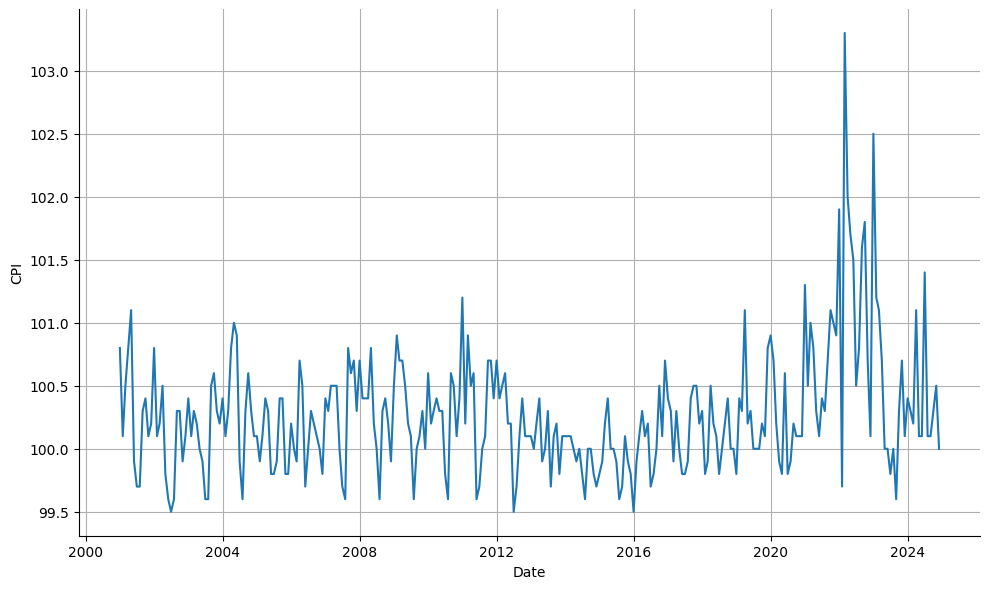

In [717]:
sns.relplot(x='Date', y='CPI', data=inflation_clean, 
            kind='line', height=6, aspect=10/6)

plt.grid()
plt.show()

In [718]:
df = inflation_clean.copy()
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date').asfreq('MS') 

model = ARIMA(df['CPI'], order=(1,1,1))
results = model.fit()

forecast = results.forecast(steps=2)
print("Forecast for the next two months:")
print(forecast)

Forecast for the next two months:
2025-01-01    100.278135
2025-02-01    100.343409
Freq: MS, Name: predicted_mean, dtype: float64


In [719]:
forecast_data = {
    "Date": ["2025-01-01", "2025-02-01"],
    "CPI": [100.78, 100.34]
}

In [720]:
inflation_final = pd.concat([inflation_clean, pd.DataFrame(forecast_data)], ignore_index=True)
inflation_final['Date'] = pd.to_datetime(inflation_final['Date'], errors='coerce')
inflation_final['Date'] = inflation_final['Date'].dt.strftime('%Y-%m')
inflation_final.tail()

,Date,CPI
285,2024-10,100.30
286,2024-11,100.50
287,2024-12,100.00
288,2025-01,100.78
289,2025-02,100.34


### Otodom Data

In [721]:
all_data.replace(["Brak danych", "brak informacji"], np.nan, inplace=True)

# Drop rows where at least 90% of columns are NaN
threshold = all_data.shape[1] * 0.1  # 10% non-NaN values required
all_data = all_data.dropna(thresh=threshold)

print(all_data.shape)

(2056, 14)


In [722]:
all_data.rename(columns={
    'URL': 'URL',
    'Cena': 'Price',
    'Cena za m²': 'Price per m²',
    'Adres': 'Address',
    'Powierzchnia (m²)': 'Area (m²)',
    'Liczba pokoi': 'Number of rooms',
    'Ogrzewanie': 'Heating',
    'Rynek': 'Market',
    'Typ ogłoszeniodawcy': 'Advertiser type',
    'Rodzaj zabudowy': 'Building type',
    'Rok budowy': 'year_const',
    'Okna': 'Windows',
    'Materiał budynku': 'Building material'
}, inplace=True)

In [723]:
all_data = all_data.drop(columns = ['URL', 'Price per m²'])

In [724]:
all_data.head()

,Price,Address,Area (m²),Number of rooms,Heating,Market,Advertiser type,Building type,year_const,Windows,Building material,type
0,1 999 000 zł,"ul. Olchowa, Ujeścisko-Łostowice, Gdańsk, pomo...",148m²,4 pokoje,gazowe,wtórny,prywatny,szeregowiec,2021,plastikowe,silikat,house
1,149 000 zł,"Nowy Las, Głuchołazy, nyski, opolskie",70m²,3 pokoje,NaN,wtórny,biuro nieruchomości,wolnostojący,NaN,NaN,NaN,house
2,949 000 zł,"Wołomin, Wołomin, wołomiński, mazowieckie",110.17m²,4 pokoje,gazowe,pierwotny,biuro nieruchomości,bliźniak,2025,plastikowe,cegła,house
3,729 000 zł,"ul. Lokalna, Płock, mazowieckie",114m²,5 pokoi,NaN,wtórny,biuro nieruchomości,bliźniak,1970,NaN,pustak,house
4,559 000 zł,"Knurów, gliwicki, śląskie",150m²,4 pokoje,NaN,wtórny,biuro nieruchomości,wolnostojący,NaN,plastikowe,cegła,house


In [725]:
all_data['Price'] = pd.to_numeric(
    all_data['Price'].str.replace(r'(zł|\s+)', '', regex=True), 
    errors='coerce'
)
all_data['Area (m²)'] = pd.to_numeric(
    all_data['Area (m²)'].str.replace(r'm²', '', regex=True), 
    errors='coerce'
)
all_data['Number of rooms'] = pd.to_numeric(
    all_data['Number of rooms'].str.replace(r'(pokoje?|pokoi)', '', regex=True), 
    errors='coerce'
)

In [726]:
all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2056 entries, 0 to 2450
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              1694 non-null   float64
 1   Address            2055 non-null   object 
 2   Area (m²)          2055 non-null   float64
 3   Number of rooms    788 non-null    float64
 4   Heating            1228 non-null   object 
 5   Market             2055 non-null   object 
 6   Advertiser type    2055 non-null   object 
 7   Building type      1284 non-null   object 
 8   year_const         1658 non-null   object 
 9   Windows            1024 non-null   object 
 10  Building material  787 non-null    object 
 11  type               2056 non-null   object 
dtypes: float64(3), object(9)
memory usage: 208.8+ KB


In [727]:
all_data['Heating'].value_counts()

Heating
miejskie                                     760
gazowe                                       229
inne                                          71
pompa ciepła                                  39
elektryczne                                   34
kotłownia                                     22
kominkowe\ngazowe                             14
węglowe                                       14
piece kaflowe                                  7
kominkowe                                      5
gazowe\npompa ciepła                           4
kominkowe gazowe                               3
biomasa                                        3
węglowe\ngazowe                                2
gazowe kolektor słoneczny                      2
elektryczne\nkominkowe                         2
kominkowe\npompa ciepła                        2
kominkowe\nolejowe                             1
pompa ciepła kolektor słoneczny                1
biomasa\nelektryczne                           1
węglowe komi

In [728]:
# Calculate the threshold (1% of total count)
threshold = all_data['Heating'].count() * 0.01  

# Get value counts
heating_counts = all_data['Heating'].value_counts()

# Find categories that occur less than the threshold
rare_categories = heating_counts[heating_counts < threshold].index

# Replace them with "Inne"
all_data['Heating'] = all_data['Heating'].replace(rare_categories, "inne")

# Display the updated value counts
print(all_data['Heating'].value_counts())

Heating
miejskie             760
gazowe               229
inne                 116
pompa ciepła          39
elektryczne           34
kotłownia             22
węglowe               14
kominkowe\ngazowe     14
Name: count, dtype: int64


In [729]:
all_data['offer_date'] = "2025-02"

In [730]:
all_data.query('Price < 100000')

,Price,Address,Area (m²),Number of rooms,Heating,Market,Advertiser type,Building type,year_const,Windows,Building material,type,offer_date
61,11400.0,"Pogorzel, Gołdap, gołdapski, warmińsko-mazurskie",57.00,2.0,NaN,wtórny,prywatny,bliźniak,1986,NaN,NaN,house,2025-02
78,18750.0,"Olbrachtów, Żary, żarski, lubuskie",115.00,3.0,NaN,wtórny,prywatny,NaN,NaN,NaN,NaN,house,2025-02
1000,65600.0,"ul. Mickiewicza, Olsztynek, Olsztynek, olsztyń...",37.40,2.0,gazowe,wtórny,prywatny,blok,1924,plastikowe,cegła,apartment,2025-02
1755,99000.0,"ul. Armii Krajowej, Chorzów Batory, Chorzów, ś...",39.67,NaN,elektryczne,wtórny,biuro nieruchomości,kamienica,NaN,plastikowe,cegła,studio,2025-02
2112,82500.0,"Śródmieście, Jelenia Góra, dolnośląskie",30.00,NaN,NaN,wtórny,biuro nieruchomości,NaN,NaN,NaN,NaN,studio,2025-02
2125,50000.0,"Aleksandrów Łódzki, Aleksandrów Łódzki, zgiers...",17.27,NaN,NaN,wtórny,prywatny,kamienica,NaN,NaN,NaN,studio,2025-02
2246,6000.0,"ok.ul. Moniuszki, Centrum, Śródmieście, Łódź, ...",50.00,NaN,miejskie,wtórny,biuro nieruchomości,kamienica,NaN,plastikowe,cegła,studio,2025-02


In [731]:
all_data = all_data.query('Price > 20000')

<function matplotlib.pyplot.show(close=None, block=None)>

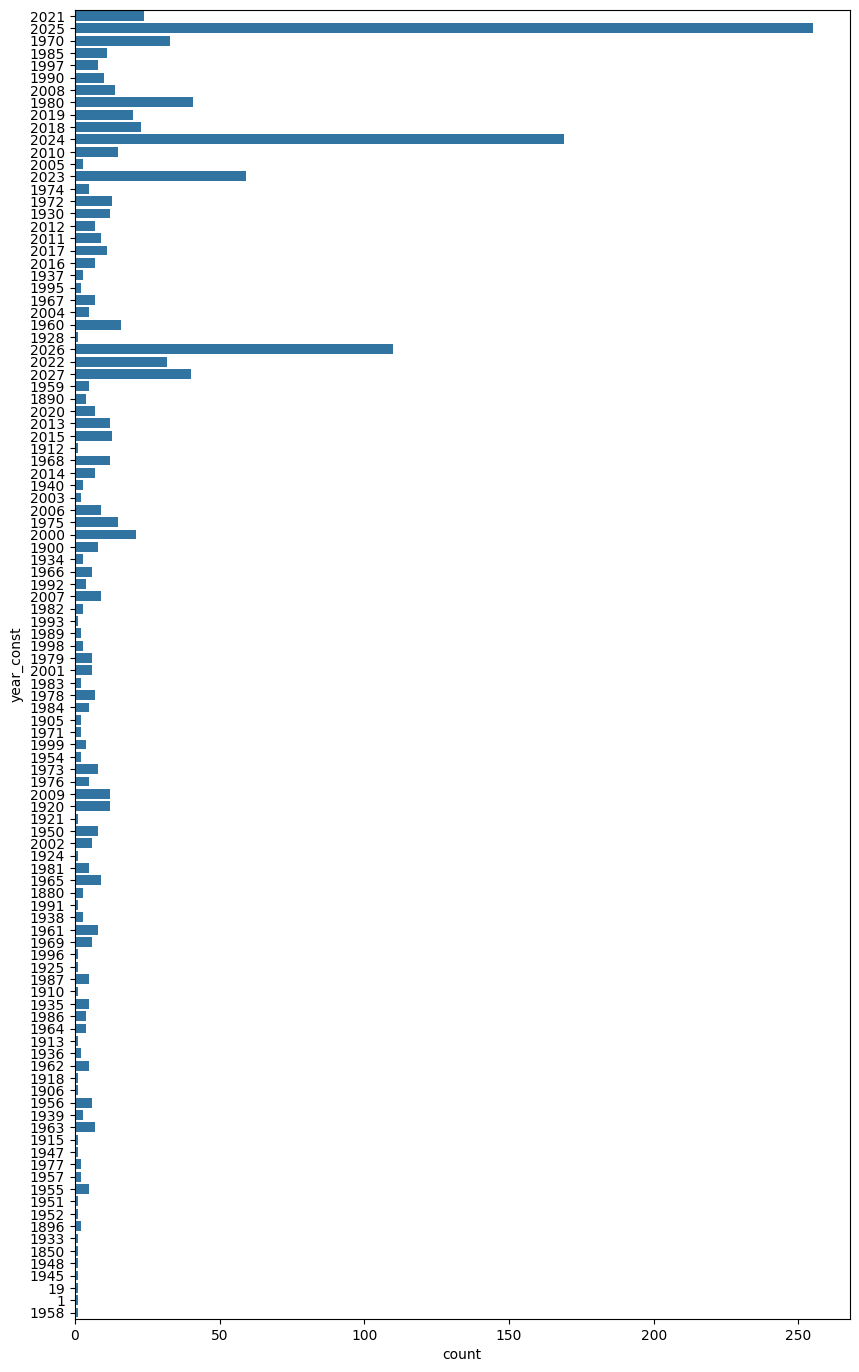

In [732]:
plt.figure(figsize=(10, 17))
sns.countplot(all_data['year_const'])
plt.show

In [733]:
all_data = all_data.query('year_const > "1800"')

### Additional Data

In [734]:
population

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Poland,POL,"Population, total",SP.POP.TOTL,29637450,29964000,30308500,30712000,31139450,31444950,...,38011735,37986412,37970087,37974826,37974750,37965475,37899070,36981559,36821749,36687353


In [735]:
population = population.T
population = population.iloc[4:,:]
population.columns = ['population']
population = population.reset_index()  
population = population.rename(columns={'index': 'Date'})
population['Date'] = population['Date'].astype(str) 

new_obs = pd.DataFrame({
    'Date': ["2024", "2025"],
    'population': [38539201, 38268383]
})

population = pd.concat([population, new_obs], ignore_index=True)

population.head()

,Date,population
0,1960,29637450
1,1961,29964000
2,1962,30308500
3,1963,30712000
4,1964,31139450


In [736]:
gur

,Kod,Nazwa,ogółem;2004;[%],ogółem;2005;[%],ogółem;2006;[%],ogółem;2007;[%],ogółem;2008;[%],ogółem;2009;[%],ogółem;2010;[%],ogółem;2011;[%],...,ogółem;2016;[%],ogółem;2017;[%],ogółem;2018;[%],ogółem;2019;[%],ogółem;2020;[%],ogółem;2021;[%],ogółem;2022;[%],ogółem;2023;[%],ogółem;2024;[%],Unnamed: 23
0,0,POLSKA,"19,0","17,6","14,8","11,2","9,5","12,1","12,4","12,5",...,"8,2","6,6","5,8","5,2","6,3","5,8","5,2","5,1","5,1",NaN


In [737]:
gur = gur.T
gur = gur.iloc[2:,:]
gur.columns = ['gur']
gur.index = gur.index.str.split(';').str[1]
gur = gur.reset_index()  
gur = gur.rename(columns={'index': 'Date'})
gur['Date'] = gur['Date'].astype(str)
gur['gur'] = pd.to_numeric(
    gur['gur'].str.replace(r',', '.', regex=True), 
    errors='coerce'
)

new_obs = pd.DataFrame({
    'Date': ["2003", "2025"],
    'gur': [20, 4]
})

gur = pd.concat([gur, new_obs], ignore_index=True)

gur.tail()

,Date,gur
19,2023,5.1
20,2024,5.1
21,nan,NaN
22,2003,20.0
23,2025,4.0


In [738]:
average_salary

,Kod,Nazwa,ogółem;2002;[zł],ogółem;2003;[zł],ogółem;2004;[zł],ogółem;2005;[zł],ogółem;2006;[zł],ogółem;2007;[zł],ogółem;2008;[zł],ogółem;2009;[zł],...,ogółem;2015;[zł],ogółem;2016;[zł],ogółem;2017;[zł],ogółem;2018;[zł],ogółem;2019;[zł],ogółem;2020;[zł],ogółem;2021;[zł],ogółem;2022;[zł],ogółem;2023;[zł],Unnamed: 24
0,0,POLSKA,"2239,56","2314,66","2409,69","2506,93","2636,81","2866,04","3158,48","3315,38",...,"4150,86","4290,52","4527,89","4834,76","5181,63","5523,32","6001,02","6705,62","7595,30",NaN


In [739]:
average_salary = average_salary.T
average_salary = average_salary.iloc[2:,:]
average_salary.columns = ['average_salary']
average_salary.index = average_salary.index.str.split(';').str[1]
average_salary = average_salary.reset_index()  
average_salary = average_salary.rename(columns={'index': 'Date'})
average_salary['Date'] = average_salary['Date'].astype(str)
average_salary['average_salary'] = pd.to_numeric(
    average_salary['average_salary'].str.replace(r',', '.', regex=True), 
    errors='coerce'
)

new_obs = pd.DataFrame({
    'Date': ["2024", "2025"],
    'average_salary': [8477, 8482.47]
})

average_salary = pd.concat([average_salary, new_obs], ignore_index=True)

average_salary.head()

,Date,average_salary
0,2002,2239.56
1,2003,2314.66
2,2004,2409.69
3,2005,2506.93
4,2006,2636.81


### Data Imputation

In [740]:
all_data.isna().sum()

Price                  0
Address                0
Area (m²)              0
Number of rooms      752
Heating              399
Market                 0
Advertiser type        0
Building type        362
year_const             0
Windows              586
Building material    683
type                   0
offer_date             0
dtype: int64

In [741]:
# Make a copy to ensure we don’t modify the original DataFrame
all_data_copy = all_data.copy()

# Separate numeric and categorical columns
numeric_cols = all_data_copy.select_dtypes(include=['number']).columns
categorical_cols = all_data_copy.select_dtypes(exclude=['number']).columns

In [742]:
### Step 1: Impute numeric columns using KNN
imputer = KNNImputer(n_neighbors=3)
numeric_data_imputed = pd.DataFrame(imputer.fit_transform(all_data_copy[numeric_cols]), 
                                    columns=numeric_cols, 
                                    index=all_data_copy.index)  # Ensure index remains the same

### Step 2: Encode categorical columns and Impute using Decision Tree
categorical_data = all_data_copy[categorical_cols].copy()

# Encode all categorical variables
label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()
    categorical_data[col] = categorical_data[col].astype(str)  # Convert NaN to string
    categorical_data[col] = encoder.fit_transform(categorical_data[col])  # Encode
    label_encoders[col] = encoder  # Save encoder for later decoding

# Ensure we maintain the same index structure
categorical_data = categorical_data.reindex(all_data_copy.index)

# Identify missing values in categorical columns and use Decision Tree to predict them
for col in categorical_cols:
    if all_data_copy[col].isna().sum() > 0:  # Only impute if there are missing values
        # Split known and missing data
        known_data = categorical_data[all_data_copy[col].notna()]
        missing_data = categorical_data[all_data_copy[col].isna()]

        # Train Decision Tree on known data
        model = DecisionTreeClassifier(max_depth=5, random_state=42)
        model.fit(known_data.drop(col, axis=1), known_data[col])

        # Predict missing values
        categorical_data.loc[missing_data.index, col] = model.predict(missing_data.drop(col, axis=1))

# Convert encoded categorical values back to original labels
for col in categorical_cols:
    categorical_data[col] = label_encoders[col].inverse_transform(categorical_data[col].astype(int))

# Ensure categorical data has the same index as original
categorical_data = categorical_data.reindex(all_data_copy.index)

### Step 3: Merge both imputed datasets
all_data_imputed = pd.concat([numeric_data_imputed, categorical_data], axis=1)

# Ensure final shape matches expected dimensions
print(f"Final shape:  {all_data_imputed.shape}")

print(f"Na's: {all_data_imputed.isna().sum()}")

all_data_imputed.head()


Final shape:  (1307, 13)
Na's: Price                0
Area (m²)            0
Number of rooms      0
Address              0
Heating              0
Market               0
Advertiser type      0
Building type        0
year_const           0
Windows              0
Building material    0
type                 0
offer_date           0
dtype: int64


,Price,Area (m²),Number of rooms,Address,Heating,Market,Advertiser type,Building type,year_const,Windows,Building material,type,offer_date
0,1999000.0,148.00,4.0,"ul. Olchowa, Ujeścisko-Łostowice, Gdańsk, pomo...",gazowe,wtórny,prywatny,szeregowiec,2021,plastikowe,silikat,house,2025-02
2,949000.0,110.17,4.0,"Wołomin, Wołomin, wołomiński, mazowieckie",gazowe,pierwotny,biuro nieruchomości,bliźniak,2025,plastikowe,cegła,house,2025-02
3,729000.0,114.00,5.0,"ul. Lokalna, Płock, mazowieckie",gazowe,wtórny,biuro nieruchomości,bliźniak,1970,plastikowe,pustak,house,2025-02
5,410000.0,82.00,5.0,"ul. Biała, Glinice, Radom, mazowieckie",gazowe,wtórny,biuro nieruchomości,wolnostojący,1985,plastikowe,cegła,house,2025-02
6,439000.0,161.00,4.0,"Barcino, Kępice, słupski, pomorskie",węglowe,wtórny,biuro nieruchomości,wolnostojący,1997,plastikowe,pustak,house,2025-02


### Generating synthetic data

In [743]:
# Compute Z-scores for the 'Price' column
z_scores = np.abs(zscore(all_data_imputed['Price']))

# Remove rows where the Z-score is above 3 (3σ rule)
all_data_imputed = all_data_imputed[z_scores < 3]

In [744]:
z_scores = np.abs(zscore(all_data_imputed['Area (m²)']))
all_data_imputed = all_data_imputed[z_scores < 3]

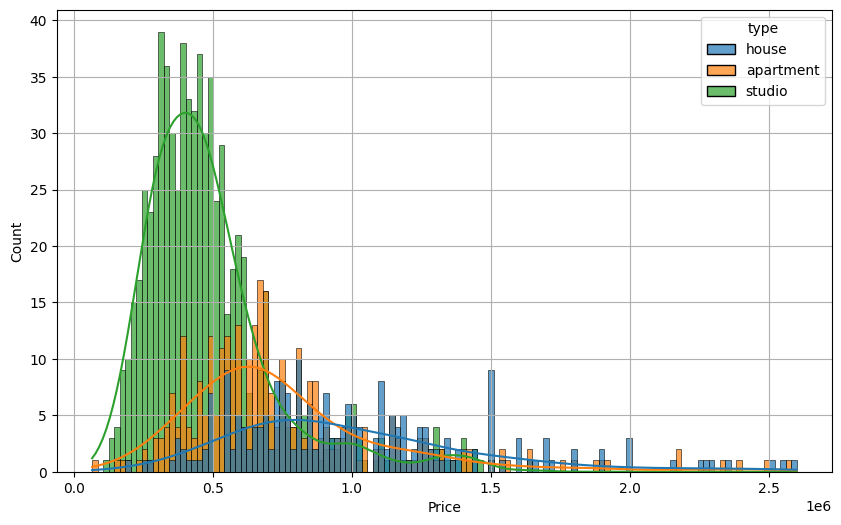

In [745]:
plt.figure(figsize=(10, 6))
sns.histplot(data=all_data_imputed, x='Price', bins=128, kde=True, alpha=0.7, hue = 'type')
plt.grid()
plt.show()


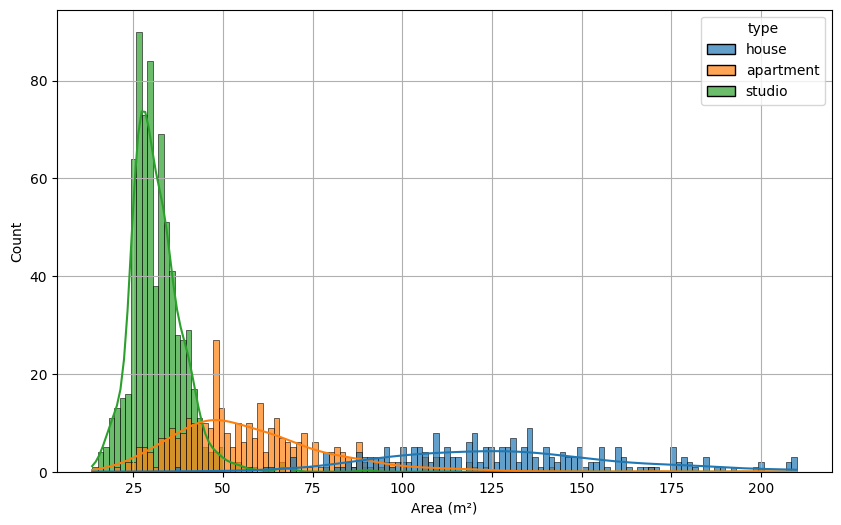

In [746]:
plt.figure(figsize=(10, 6))
sns.histplot(data=all_data_imputed, x='Area (m²)', bins=128, kde=True, alpha=0.7, hue = 'type')
plt.grid()
plt.show()

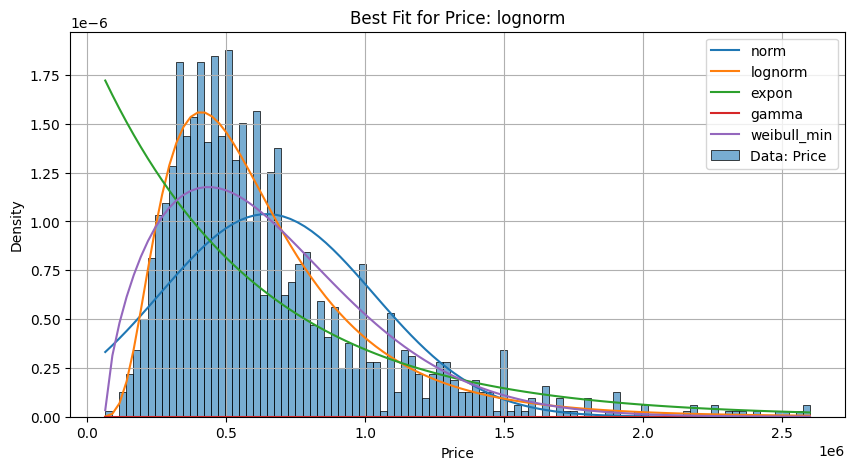

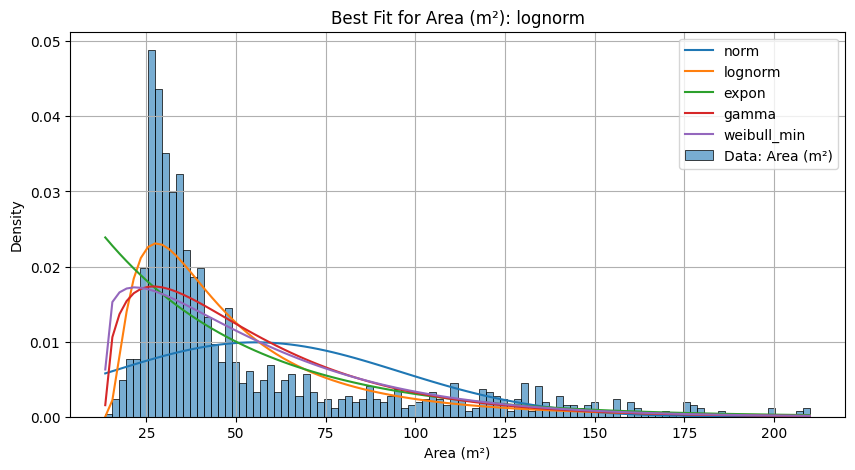

Best-fitting distribution for Price: lognorm
Best-fitting distribution for Area (m²): lognorm


In [747]:
# Select only numeric columns
numeric_cols = all_data_imputed[['Price', 'Area (m²)']]

# List of common distributions to test
dist_names = ['norm', 'lognorm', 'expon', 'gamma', 'weibull_min']

best_fits = {}

# Loop through each numeric column
for col in numeric_cols:
    data = all_data_imputed[col].dropna()

    plt.figure(figsize=(10, 5))
    sns.histplot(data, bins=100, kde=False, stat="density", label=f"Data: {col}", alpha=0.6)

    best_pval = 0
    best_dist = None

    for dist in dist_names:
        # Fit distribution
        params = getattr(stats, dist).fit(data)
        
        # Generate PDF from fitted distribution
        x = np.linspace(data.min(), data.max(), 100)
        pdf_fitted = getattr(stats, dist).pdf(x, *params)

        # Kolmogorov-Smirnov test
        ks_stat, ks_pval = stats.kstest(data, dist, args=params)

        # Track the best distribution
        if ks_pval > best_pval:
            best_pval = ks_pval
            best_dist = dist

        # Plot distribution
        plt.plot(x, pdf_fitted, label=f"{dist}")

    best_fits[col] = best_dist
    plt.legend()
    plt.grid()
    plt.title(f"Best Fit for {col}: {best_dist}")
    plt.show()

# Print the best distribution for each feature
for col, dist in best_fits.items():
    print(f"Best-fitting distribution for {col}: {dist}")

In [748]:
import pandas as pd
import numpy as np

# -----------------------------------------------------
# 1. Base data: offers from 2025-02
# -----------------------------------------------------
df_base = all_data_imputed.copy()
df_base = df_base[df_base['offer_date'] == "2025-02"]
df_base = df_base[(df_base['Price'] > 0) & (df_base['Area (m²)'] > 0)]

# Ensure that the "year_const" column is numeric
df_base['year_const'] = df_base['year_const'].astype(int)

# -----------------------------------------------------
# 2. Calculate log-price (Price) and log-area (Area) parameters for each type
# -----------------------------------------------------
group_params_price = {}
group_params_area = {}

# Assume we have three types: studio, apartment, house.
types_list = ['studio', 'apartment', 'house']

for t in types_list:
    subset_t = df_base[df_base['type'] == t]
    
    # Price parameters (based on logarithms)
    log_prices_t = np.log(subset_t['Price'])
    mu_price_t = log_prices_t.mean()
    sigma_price_t = log_prices_t.std()
    group_params_price[t] = (mu_price_t, sigma_price_t)
    
    # Area parameters
    log_areas_t = np.log(subset_t['Area (m²)'])
    mu_area_t = log_areas_t.mean()
    sigma_area_t = log_areas_t.std()
    group_params_area[t] = (mu_area_t, sigma_area_t)

# -----------------------------------------------------
# 3. Inflation data
# -----------------------------------------------------
# inflation_final contains columns: 'Date' (format "YYYY-MM") and 'CPI'
baseline_date = "2025-02"
baseline_cpi = inflation_final.loc[inflation_final['Date'] == baseline_date, 'CPI'].iloc[0]

# -----------------------------------------------------
# 4. Sampling additional columns: Advertiser type and Market
# -----------------------------------------------------
adv_probs = df_base['Advertiser type'].value_counts(normalize=True)
market_probs = df_base['Market'].value_counts(normalize=True)

# -----------------------------------------------------
# 5. Prepare the date range (2003-01 to 2024-12)
# -----------------------------------------------------
date_range = pd.date_range(start="2003-01-01", end="2024-12-01", freq="MS")
date_range_str = date_range.strftime("%Y-%m")

# Fixed number of offers per month: 30 for each type (studio, apartment, house)
n_offers_per_type = 30

# -----------------------------------------------------
# 6. Generate synthetic data
# -----------------------------------------------------
new_rows = []

for current_date in date_range_str:
    # Get the CPI for the current month
    row_cpi = inflation_final.loc[inflation_final['Date'] == current_date, 'CPI']
    if row_cpi.empty:
        continue
    cpi_current = row_cpi.iloc[0]
    
    # Calculate the inflation adjustment (in log scale)
    # If the CPI for the current month is lower than in 2025-02,
    # the result will be negative, lowering the log-mean of prices.
    alpha_infl = np.log(cpi_current / baseline_cpi)
    
    # Extract the offer year from current_date (e.g., "2003-02" -> 2003)
    offer_year = int(current_date.split("-")[0])
    
    for chosen_type in types_list:
        # Price parameters for the given type
        mu_price_type, sigma_price_type = group_params_price[chosen_type]
        mu_price_final = mu_price_type + alpha_infl  # inflation adjustment
        # Area parameters (without inflation adjustment)
        mu_area_type, sigma_area_type = group_params_area[chosen_type]
        
        for _ in range(n_offers_per_type):
            # Sample price and area from the lognormal distribution
            generated_price = np.random.lognormal(mean=mu_price_final, sigma=sigma_price_type)
            generated_area = np.random.lognormal(mean=mu_area_type, sigma=sigma_area_type)
            
            # Sample Advertiser type and Market based on proportions from df_base
            chosen_adv = np.random.choice(adv_probs.index, p=adv_probs.values)
            chosen_market = np.random.choice(market_probs.index, p=market_probs.values)
            
            # Sample additional columns from the original dataset for the given type
            sample_record = df_base[df_base['type'] == chosen_type].sample(n=1).iloc[0]
            building_type = sample_record['Building type']
            windows = sample_record['Windows']
            building_material = sample_record['Building material']
            address = sample_record['Address']
            heating = sample_record['Heating']
            
            # Sample "year_const" from the original data for the given type.
            # If the sampled construction year exceeds the synthetic offer year, set it equal to the offer year.
            sampled_year_const = int(
                df_base[df_base['type'] == chosen_type]['year_const'].sample(n=1).iloc[0]
            )
            if sampled_year_const > offer_year:
                sampled_year_const = offer_year
            
            # Sample the number of rooms depending on the type:
            if chosen_type == 'studio':
                number_rooms = np.random.randint(1, 3)  # 1 or 2
            elif chosen_type == 'apartment':
                number_rooms = np.random.randint(2, 5)  # 2, 3, or 4
            elif chosen_type == 'house':
                number_rooms = np.random.randint(4, 11)  # from 4 to 10
            else:
                number_rooms = np.nan  # fallback
            
            new_record = {
                "offer_date": current_date,
                "type": chosen_type,
                "Advertiser type": chosen_adv,
                "Market": chosen_market,
                "Building type": building_type,
                "Windows": windows,
                "Building material": building_material,
                "Heating": heating,
                "Address": address,
                "year_const": sampled_year_const,
                "Number of rooms": number_rooms,
                "Price": generated_price,
                "Area (m²)": generated_area
            }
            new_rows.append(new_record)

df_generated = pd.DataFrame(new_rows).reset_index(drop=True)
print(f"Number of generated records: {len(df_generated)}")
print(df_generated.head())

# Optionally: save to a CSV file
# df_generated.to_csv("generated_data_monthly_complete_with_rooms_heating.csv", index=False)


Number of generated records: 23760
  offer_date    type      Advertiser type  Market    Building type  \
0    2003-01  studio  biuro nieruchomości  wtórny             blok   
1    2003-01  studio             prywatny  wtórny  apartamentowiec   
2    2003-01  studio  biuro nieruchomości  wtórny             blok   
3    2003-01  studio  biuro nieruchomości  wtórny             blok   
4    2003-01  studio  biuro nieruchomości  wtórny             blok   

      Windows Building material   Heating  \
0  plastikowe      wielka płyta  miejskie   
1  plastikowe              inny  miejskie   
2  plastikowe              inny  miejskie   
3  plastikowe              inny  miejskie   
4  plastikowe      wielka płyta  miejskie   

                                             Address  year_const  \
0                       Północ, Częstochowa, śląskie        2003   
1  ul. Mariana Smoluchowskiego, Junikowo, Grunwal...        2003   
2        Grzegórzki, Grzegórzki, Kraków, małopolskie        1970   
3

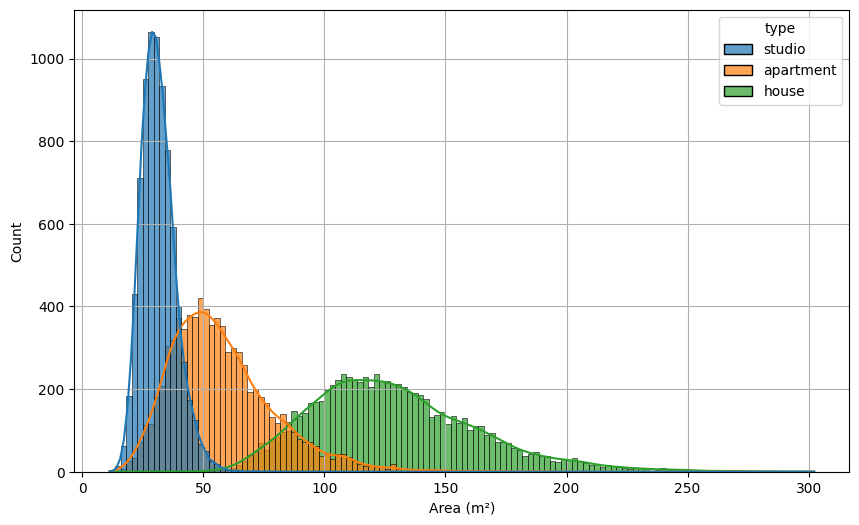

In [749]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_generated, x='Area (m²)', bins=128, kde=True, alpha=0.7, hue = 'type')
plt.grid()
plt.show()

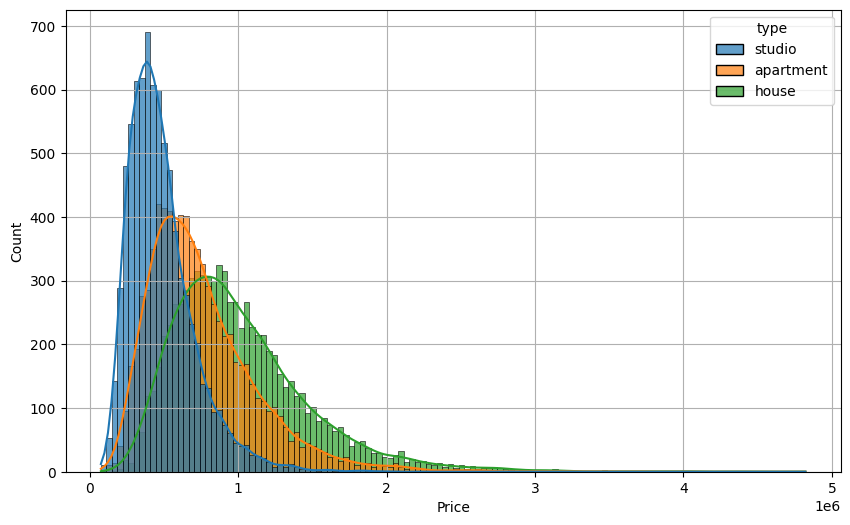

In [750]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_generated, x='Price', bins=128, kde=True, alpha=0.7, hue = 'type')
plt.grid()
plt.show()

In [751]:
df_generated.groupby('type')['Price'].mean()

type
apartment    7.561704e+05
house        1.016434e+06
studio       4.819918e+05
Name: Price, dtype: float64

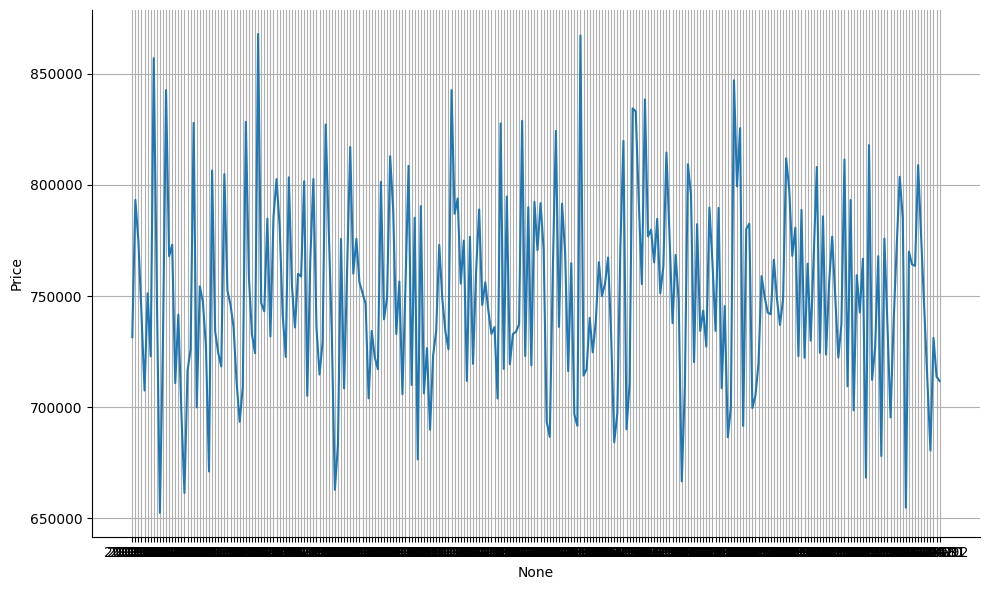

In [752]:
result = pd.DataFrame(df_generated.groupby('offer_date').agg({'Price': 'mean'}).to_dict())
sns.relplot(x=result.index, y='Price', data=result, 
            kind='line', height=6, aspect=10/6)

plt.grid()
plt.show()

### Data Finalize 

In [753]:
data_final = pd.concat([all_data_imputed, df_generated], ignore_index=True)
data_final = data_final.merge(inflation_final, left_on = 'offer_date', right_on = 'Date', how = 'left')

data_final['Date'] = pd.to_datetime(data_final['Date'], format='%Y-%m').dt.year
data_final['Date'] = data_final['Date'].astype(str)

data_final = data_final.merge(population, on='Date', how='left')
data_final = data_final.merge(gur, on='Date', how='left')
data_final = data_final.merge(average_salary, on='Date', how='left')

data_final['voivodeship'] = data_final['Address'].str.split(',').str[-1].str.strip()

In [754]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25021 entries, 0 to 25020
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Price              25021 non-null  float64
 1   Area (m²)          25021 non-null  float64
 2   Number of rooms    25021 non-null  float64
 3   Address            25021 non-null  object 
 4   Heating            25021 non-null  object 
 5   Market             25021 non-null  object 
 6   Advertiser type    25021 non-null  object 
 7   Building type      25021 non-null  object 
 8   year_const         25021 non-null  object 
 9   Windows            25021 non-null  object 
 10  Building material  25021 non-null  object 
 11  type               25021 non-null  object 
 12  offer_date         25021 non-null  object 
 13  Date               25021 non-null  object 
 14  CPI                25021 non-null  float64
 15  population         25021 non-null  object 
 16  gur                250

In [755]:
data_final.head()

,Price,Area (m²),Number of rooms,Address,Heating,Market,Advertiser type,Building type,year_const,Windows,Building material,type,offer_date,Date,CPI,population,gur,average_salary,voivodeship
0,1999000.0,148.00,4.0,"ul. Olchowa, Ujeścisko-Łostowice, Gdańsk, pomo...",gazowe,wtórny,prywatny,szeregowiec,2021,plastikowe,silikat,house,2025-02,2025,100.34,38268383,4.0,8482.47,pomorskie
1,949000.0,110.17,4.0,"Wołomin, Wołomin, wołomiński, mazowieckie",gazowe,pierwotny,biuro nieruchomości,bliźniak,2025,plastikowe,cegła,house,2025-02,2025,100.34,38268383,4.0,8482.47,mazowieckie
2,729000.0,114.00,5.0,"ul. Lokalna, Płock, mazowieckie",gazowe,wtórny,biuro nieruchomości,bliźniak,1970,plastikowe,pustak,house,2025-02,2025,100.34,38268383,4.0,8482.47,mazowieckie
3,410000.0,82.00,5.0,"ul. Biała, Glinice, Radom, mazowieckie",gazowe,wtórny,biuro nieruchomości,wolnostojący,1985,plastikowe,cegła,house,2025-02,2025,100.34,38268383,4.0,8482.47,mazowieckie
4,439000.0,161.00,4.0,"Barcino, Kępice, słupski, pomorskie",węglowe,wtórny,biuro nieruchomości,wolnostojący,1997,plastikowe,pustak,house,2025-02,2025,100.34,38268383,4.0,8482.47,pomorskie


In [756]:
data_final.to_csv('data_final.csv')